In [42]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error,mean_absolute_error,
    r2_score,confusion_matrix,
    accuracy_score,precision_score,
    recall_score,f1_score,
    roc_auc_score,classification_report,
    RocCurveDisplay,
)

### Q#1

In [43]:
data = {
    'Age': ['25', '30', '35', '40', '45'],
    'Income': ['$1000.5', '$1500.0', '$2000.75', '?', '$3000.25'],
    'Signup_Date': ['2023-01-15', '2023-02-20', '2023-03-25', '2023-04-30', '2023-05-05'],
    'Color': ['Red', 'Blue', 'Green', 'Red', 'Blue'],
    'Score': [85, 90, 78, 92, 88]
}

df = pd.DataFrame(data)

print("=== Datatypes BEFORE cleaning ===")
print(df.dtypes)

=== Datatypes BEFORE cleaning ===
Age            object
Income         object
Signup_Date    object
Color          object
Score           int64
dtype: object


In [44]:
df['Age'] = pd.to_numeric(df['Age'])
df['Income'] = df['Income'].replace('?', np.nan)
df['Income'] = df['Income'].str.replace('$', '', regex=False).astype(float)
df['Signup_Date'] = pd.to_datetime(df['Signup_Date'])
df['Color'] = df['Color'].astype('category')

In [45]:
print("=== Datatypes AFTER cleaning ===")
print(df.dtypes)

=== Datatypes AFTER cleaning ===
Age                     int64
Income                float64
Signup_Date    datetime64[ns]
Color                category
Score                   int64
dtype: object


In [46]:
print("=== Cleaned DataFrame ===")
print(df)

=== Cleaned DataFrame ===
   Age   Income Signup_Date  Color  Score
0   25  1000.50  2023-01-15    Red     85
1   30  1500.00  2023-02-20   Blue     90
2   35  2000.75  2023-03-25  Green     78
3   40      NaN  2023-04-30    Red     92
4   45  3000.25  2023-05-05   Blue     88


### Q#2

In [47]:
df = pd.read_csv("Life_Expectancy_Data.csv")

# Hidden spaces fix 
df.columns = df.columns.str.strip()


In [48]:
df.head()

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             2938 non-null   int64  
 1   Status                           2938 non-null   object 
 2   Life expectancy                  2928 non-null   float64
 3   Adult Mortality                  2928 non-null   float64
 4   infant deaths                    2938 non-null   int64  
 5   Alcohol                          2744 non-null   float64
 6   percentage expenditure           2938 non-null   float64
 7   Hepatitis B                      2385 non-null   float64
 8   Measles                          2938 non-null   int64  
 9   BMI                              2904 non-null   float64
 10  under-five deaths                2938 non-null   int64  
 11  Polio                            2919 non-null   float64
 12  Total expenditure   

In [50]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [51]:
df.isnull().sum()

Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
thinness  1-19 years                34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
dtype: int64

In [52]:
df = df.drop(columns=['Population', 'GDP'])
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


In [53]:
print("Shape after cleaning:", df.shape)

Shape after cleaning: (2938, 19)


In [54]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Duplicates: 0
Shape after removing duplicates: (2938, 19)


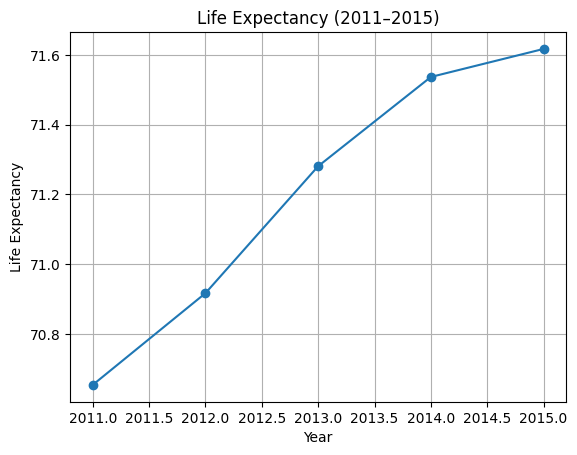

In [55]:
subset = df[(df['Year'] >= 2011) & (df['Year'] <= 2015)]
avg_life = subset.groupby('Year')['Life expectancy'].mean()

plt.figure()
plt.plot(avg_life.index, avg_life.values, marker='o')
plt.title("Life Expectancy (2011–2015)")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.grid(True)
plt.show()


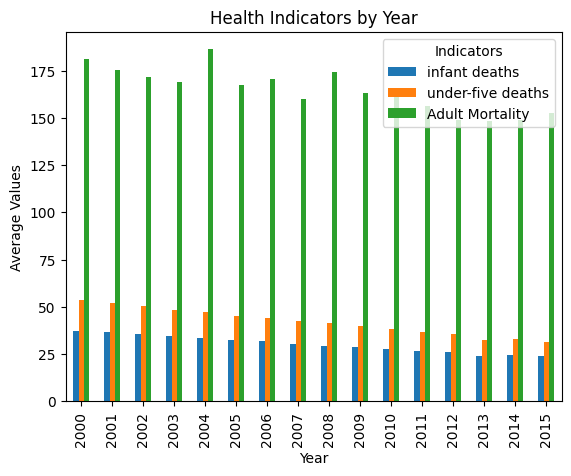

In [56]:
variables = ['infant deaths', 'under-five deaths', 'Adult Mortality']
grouped = df.groupby('Year')[variables].mean()

grouped.plot(kind='bar')
plt.title("Health Indicators by Year")
plt.ylabel("Average Values")
plt.xlabel("Year")
plt.legend(title="Indicators")
plt.show()


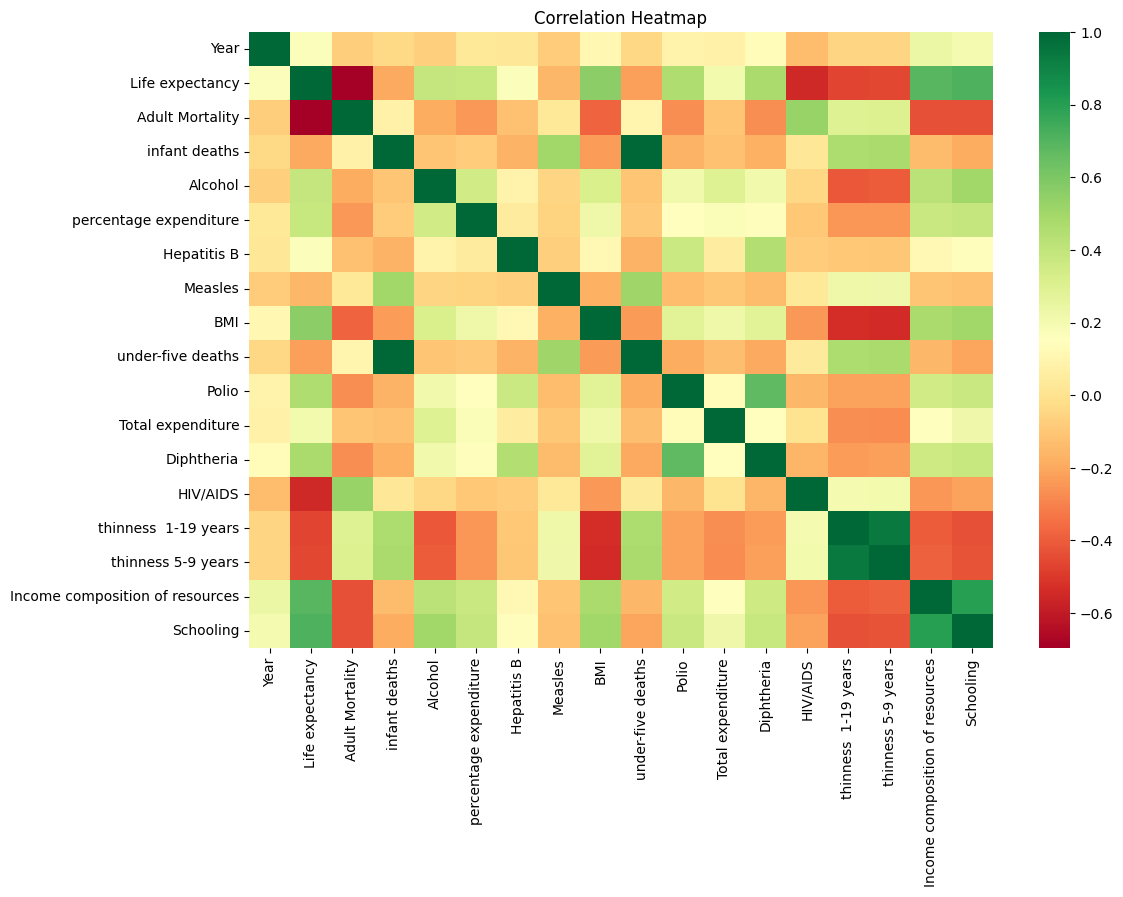

In [57]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='RdYlGn')
plt.title("Correlation Heatmap")
# plt.xlabel("Variables")
# plt.ylabel("Variables")
# plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


In [58]:
life_corr = corr['Life expectancy'].abs().sort_values(ascending=False)
print(life_corr)

Life expectancy                    1.000000
Schooling                          0.713054
Adult Mortality                    0.696390
Income composition of resources    0.688662
BMI                                0.556901
HIV/AIDS                           0.556703
Diphtheria                         0.472211
thinness  1-19 years               0.468002
thinness 5-9 years                 0.462473
Polio                              0.458399
Alcohol                            0.388918
percentage expenditure             0.381418
under-five deaths                  0.222738
Total expenditure                  0.208844
infant deaths                      0.196769
Year                               0.170819
Hepatitis B                        0.170219
Measles                            0.157767
Name: Life expectancy, dtype: float64


In [59]:
least_corr = life_corr.tail(3).index
print("Dropping:", least_corr)
df = df.drop(columns=least_corr)

Dropping: Index(['Year', 'Hepatitis B', 'Measles'], dtype='object')


In [60]:
df.to_csv("cleaned.csv", index=False)

### Q#3

In [61]:
x = df.drop(columns=['Life expectancy'])
y = df['Life expectancy']

In [62]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [63]:
num_cols = x.select_dtypes(include=['int64', 'float64']).columns
print("Numerical columns:", num_cols)

Numerical columns: Index(['Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure',
       'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria',
       'HIV/AIDS', 'thinness  1-19 years', 'thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')


In [64]:
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [65]:
cat_cols = x.select_dtypes(include=['object']).columns
print("Categorical columns:", cat_cols)

Categorical columns: Index(['Status'], dtype='object')


In [66]:
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# Columns Alignment
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [67]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results:")
print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Linear Regression Results:
MSE: 15.231843068078572
MAE: 2.849186135186218
RMSE: 3.9027993886540684
R2: 0.8242493813619383


In [68]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Results:")
print("MSE:", mse_rf)
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)


Random Forest Results:
MSE: 2.7421532653061145
MAE: 1.069704081632652
RMSE: 1.6559448255621667
R2: 0.9683600250722171


The Random Forest model performed better than Linear Regression as it achieved lower MSE, MAE, and RMSE, along with a higher R² score. This indicates that Random Forest is better at capturing complex, non-linear relationships in the dataset

### Q#4

In [69]:
x = df.drop(columns=['Status'])
y = df['Status']

In [70]:
X_train, X_test, y_train, y_test = train_test_split(x, y, train_size=0.7, random_state=42)

In [71]:
num_cols = x.select_dtypes(include=['int64', 'float64']).columns
print("Numerical columns:", num_cols)

Numerical columns: Index(['Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol',
       'percentage expenditure', 'BMI', 'under-five deaths', 'Polio',
       'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')


In [72]:
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [73]:
cat_cols = x.select_dtypes(include=['object']).columns
print("Categorical columns:", cat_cols)

Categorical columns: Index([], dtype='object')


In [74]:
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [75]:
lr_clf = LogisticRegression(max_iter=1000)
lr_clf.fit(X_train, y_train)
y_pred_lr = lr_clf.predict(X_test)
y_prob_lr = lr_clf.predict_proba(X_test)[:, 1]

In [76]:
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]

In [77]:
print("Logistic Regression Results:")

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, pos_label='Developing'))
print("Recall:", recall_score(y_test, y_pred_lr, pos_label='Developing'))
print("F1 Score:", f1_score(y_test, y_pred_lr, pos_label='Developing'))
print("AUC:", roc_auc_score((y_test=='Developing').astype(int), y_prob_lr))


Logistic Regression Results:
Confusion Matrix:
 [[122  23]
 [ 32 705]]
Accuracy: 0.937641723356009
Precision: 0.9684065934065934
Recall: 0.9565807327001357
F1 Score: 0.962457337883959
AUC: 0.97107565620175


In [78]:
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


Classification Report:
               precision    recall  f1-score   support

   Developed       0.79      0.84      0.82       145
  Developing       0.97      0.96      0.96       737

    accuracy                           0.94       882
   macro avg       0.88      0.90      0.89       882
weighted avg       0.94      0.94      0.94       882



In [79]:
print("=== Random Forest Results: ===")

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, pos_label='Developing'))
print("Recall:", recall_score(y_test, y_pred_rf, pos_label='Developing'))
print("F1 Score:", f1_score(y_test, y_pred_rf, pos_label='Developing'))
print("AUC:", roc_auc_score((y_test=='Developing').astype(int), y_prob_rf))

=== Random Forest Results: ===
Confusion Matrix:
 [[139   6]
 [  4 733]]
Accuracy: 0.9886621315192744
Precision: 0.9918809201623816
Recall: 0.994572591587517
F1 Score: 0.9932249322493225
AUC: 0.9987507603050577


In [80]:
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Classification Report:
               precision    recall  f1-score   support

   Developed       0.97      0.96      0.97       145
  Developing       0.99      0.99      0.99       737

    accuracy                           0.99       882
   macro avg       0.98      0.98      0.98       882
weighted avg       0.99      0.99      0.99       882



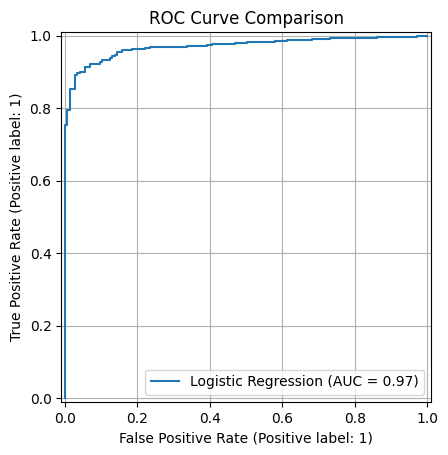

In [81]:
RocCurveDisplay.from_predictions((y_test=='Developing').astype(int), y_prob_lr, name="Logistic Regression")
plt.title("ROC Curve Comparison")
plt.grid(True)
plt.show()

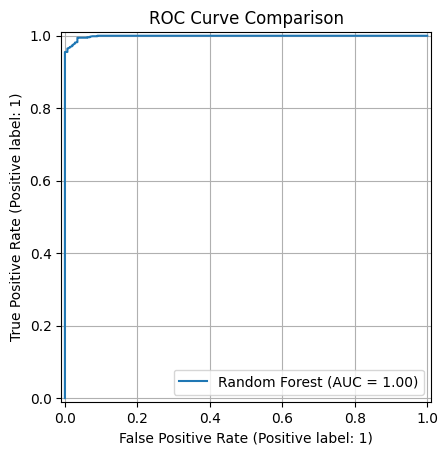

In [82]:
RocCurveDisplay.from_predictions((y_test=='Developing').astype(int), y_prob_rf, name="Random Forest")
plt.title("ROC Curve Comparison")
plt.grid(True)
# plt.legend()
plt.show()

## Conclusion:
The Random Forest classifier outperformed Logistic Regression by achieving higher accuracy, precision, recall, and F1-score.